In [1]:
from fvtools.prepro.BuildCase import BuildCase
import matplotlib.pyplot as plt

## Make the mesh related input files (depth will be made by the nesting routine)


Building case: Seaweed from: v2_with_nodestrings_with_nest.2dm with bathymetry from: troms_topo.npy in carthesian coordinates

---
Grid:
    # nodes:            48803
    # triangles:        93524
    minimum angle:      16.11
    minimum resolution: 67.83 m
    # triangles <35 degrees: 1

Settings:
    sponge radius: 0
    sponge factor: 0
    minimum depth: 5.0
    rx0 target:    0.2
    laplacian smoothing factor: 0.2

Sources:
    2dm file:      v2_with_nodestrings_with_nest.2dm
    - projection: epsg:32633

    depth file:    /cluster/work/projects/nn9238k/hes/topo/troms_topo.npy
    - projection: epsg:32633

Target projection: epsg:32633
----

- Check boundary triangles
  - Did not find triangles with more than one side facing the boundary
- Reading the sigma file to check if it contains valid information
- Compute nbsn, ntsn
- Interpolate depth to mesh
  - Crop the bathymetry data
  - Build interpolator
  - Interpolate topography to nodes
  - The depth at 6322 points was set eq

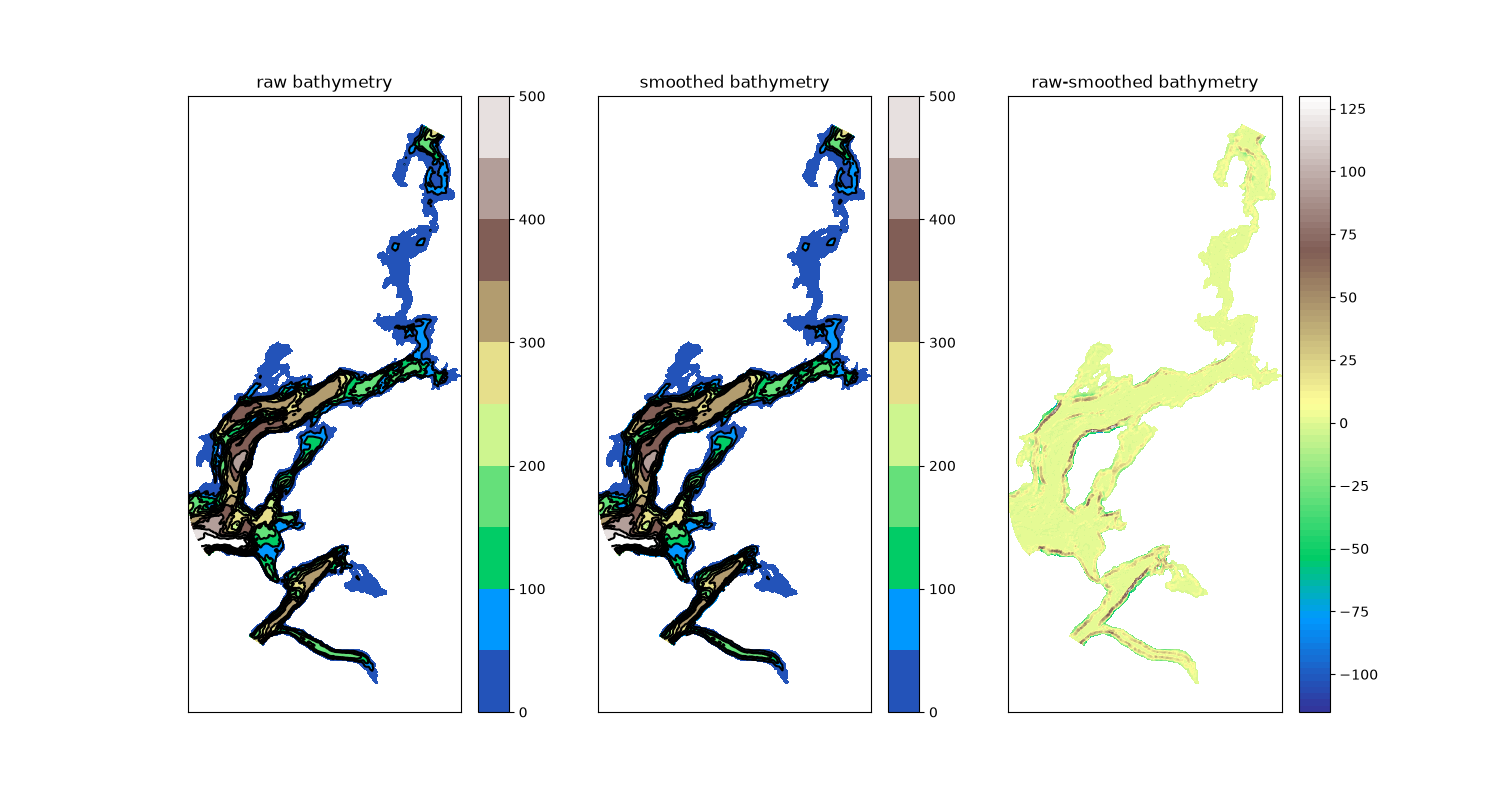

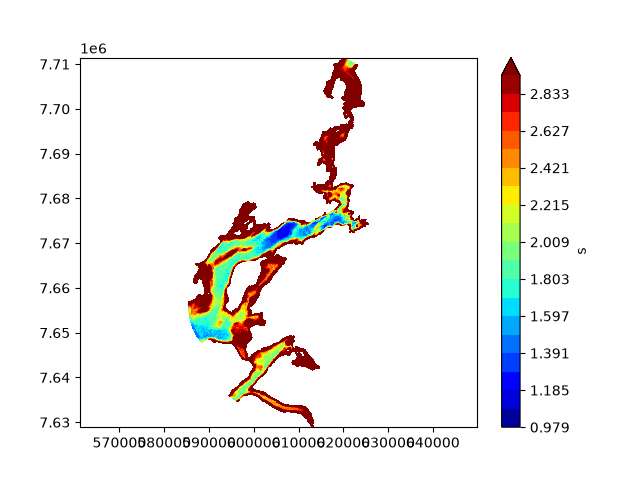

In [2]:
%matplotlib widget
exp = BuildCase(dmfile = 'v2_with_nodestrings_with_nest.2dm', depth_file = '/cluster/work/projects/nn9238k/hes/topo/troms_topo.npy', sigma_file = 'input/Seaweed_sigma.dat', casename = 'Seaweed')

## Cut the nesting zone out from the main grid

In [4]:
import fvtools.nesting.get_ngrd as gn
import numpy as np

Computing nestzone metrics
- Number of nodestrings: 3
- Cut nestzone out of mesh
- Computing triangle, grid, elements (TGE) - this may take some minutes for large grids
  -> Find the necessary cells
  -> Create nest triangulation
- Projecting latlon
- Find nearest mesh points in the FVCOM model:


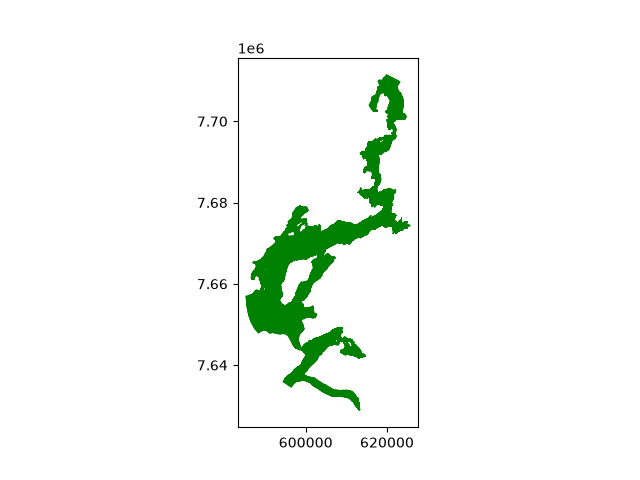

In [5]:
%matplotlib widget
gn.main('M.npy', nrows = 4, remove_land_squares = True)

# Make the boundary forcing

In [6]:
# --> first priority is to get the NorFjords object up and running

In [7]:
import fvtools.nesting.roms_nesting_fg as rn

In [8]:
%matplotlib widget
rn.main('M.npy', 'ngrd.npy', 'nest_2017.nc', '2017-09-05', '2017-12-01', mother = 'IMR-NF', latlon = True, nprocs = 8)


Interpolate data from Havforskningsinstituttet Norfjords simulations to nest_2017.nc
---
- Load mesh info
- Assuming that norfjords data is available under /cluster/work/projects/nn9238k/norfjords/
- Compute FVCOM nesting nudging coefficients as function of distance from OBC

Make the filelist
---
  - checking: /cluster/work/projects/nn9238k/norfjords/2017/norfjords_160m_his.nc4_2017090501-2017090600
  - checking: /cluster/work/projects/nn9238k/norfjords/2017/norfjords_160m_his.nc4_2017090601-2017090700
  - checking: /cluster/work/projects/nn9238k/norfjords/2017/norfjords_160m_his.nc4_2017090701-2017090800
  - checking: /cluster/work/projects/nn9238k/norfjords/2017/norfjords_160m_his.nc4_2017090801-2017090900
  - checking: /cluster/work/projects/nn9238k/norfjords/2017/norfjords_160m_his.nc4_2017090901-2017091000
  - checking: /cluster/work/projects/nn9238k/norfjords/2017/norfjords_160m_his.nc4_2017091001-2017091100
  - checking: /cluster/work/projects/nn9238k/norfjords/2017/norfjords_

  - Interpolating and dumping timesteps to nest: 100%|        ########## |Time:  0:04:241



--> Fin.


# Make the restartfile

In [9]:
import fvtools.prepro.interpol_roms_restart as ir

In [10]:
ir.main(restart_date = '2017-09-08-00', mother = 'IMR-NF', uv = True)

Load the FVCOM grid and make an empty restartfile
- Create Seaweed_initial.nc


Interpolate data from Havforskningsinstituttet Norfjords simulations to Seaweed_initial.nc
---
- Assuming that norfjords data is available under /cluster/work/projects/nn9238k/norfjords/

Compute interpolation coefficients
  - Finding nearest 4 rho weights
  - Finding nearest 4 u weights
  - Finding nearest 4 v weights
    - Adjust interpolation coefficients to remove land

Update zeta in domain (needed for vertical interpolation)
  - checking: /cluster/work/projects/nn9238k/norfjords/2017/norfjords_160m_his.nc4_2017090601-2017090700
  - checking: /cluster/work/projects/nn9238k/norfjords/2017/norfjords_160m_his.nc4_2017090701-2017090800
  - checking: /cluster/work/projects/nn9238k/norfjords/2017/norfjords_160m_his.nc4_2017090801-2017090900

Vertical interpolation coefficients
  - Finding vertical rho weights:
  - Finding vertical u weights:
  - Finding vertical v weights:

Interpolate and store ROMS hydrogr

# Make the river forcing

In [1]:
import fvtools.prepro.BuildRivers as br

In [2]:
info = br.get_input()

----------------------------------------------------------------------------
                       BuildRivers: Seaweed
----------------------------------------------------------------------------
Compute grid connectivity and identify landpoints
- Identify boundary nodes and cells...
  - build triangulation
  - find neighbors
  - isolate the nodes and cells in the domain from those near the boundary
  - seperate land boundaries from the obc

Subset the river database to cover the model domain
- Adjust river positions and remove rivers that do not drain to the model domain
 - iteration 1


Button(button_style='success', description='Done', icon='check', style=ButtonStyle())

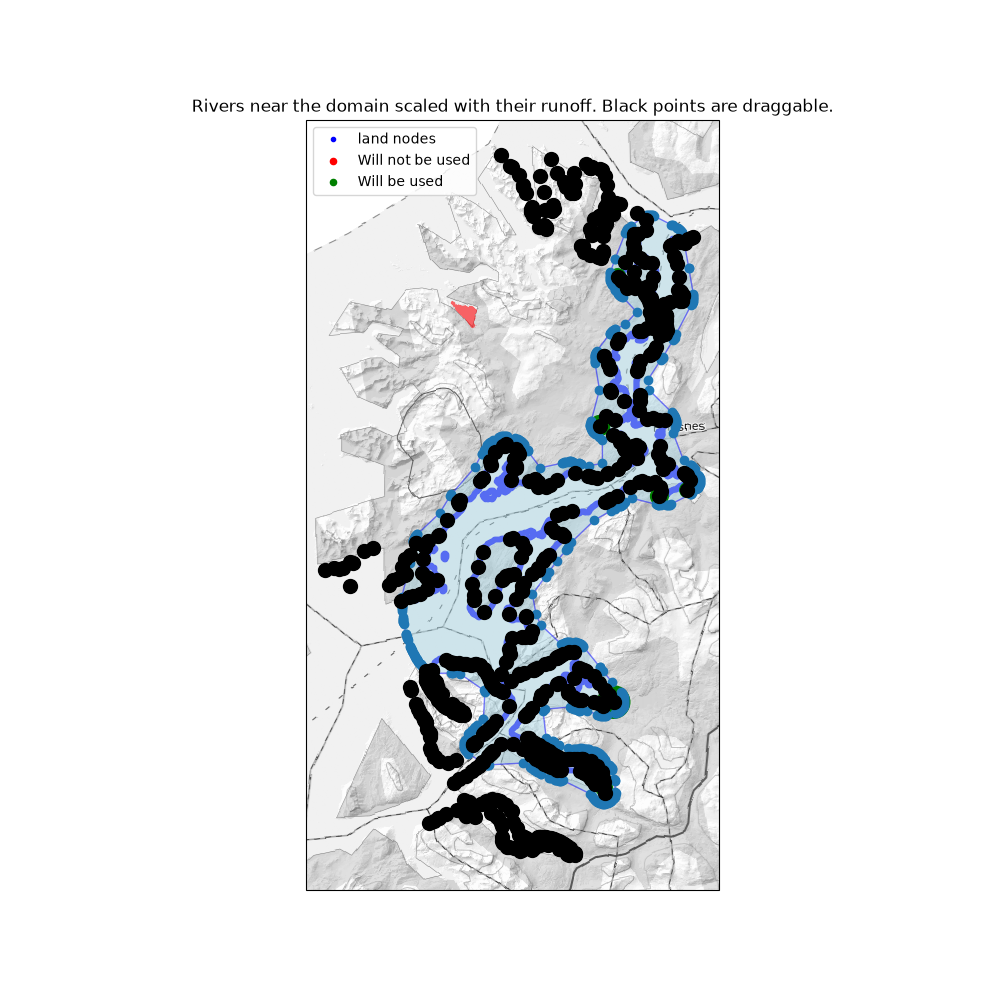

  - One or more river was modified, making a new river mask and illustrating.
 - iteration 2


Button(button_style='success', description='Done', icon='check', style=ButtonStyle())

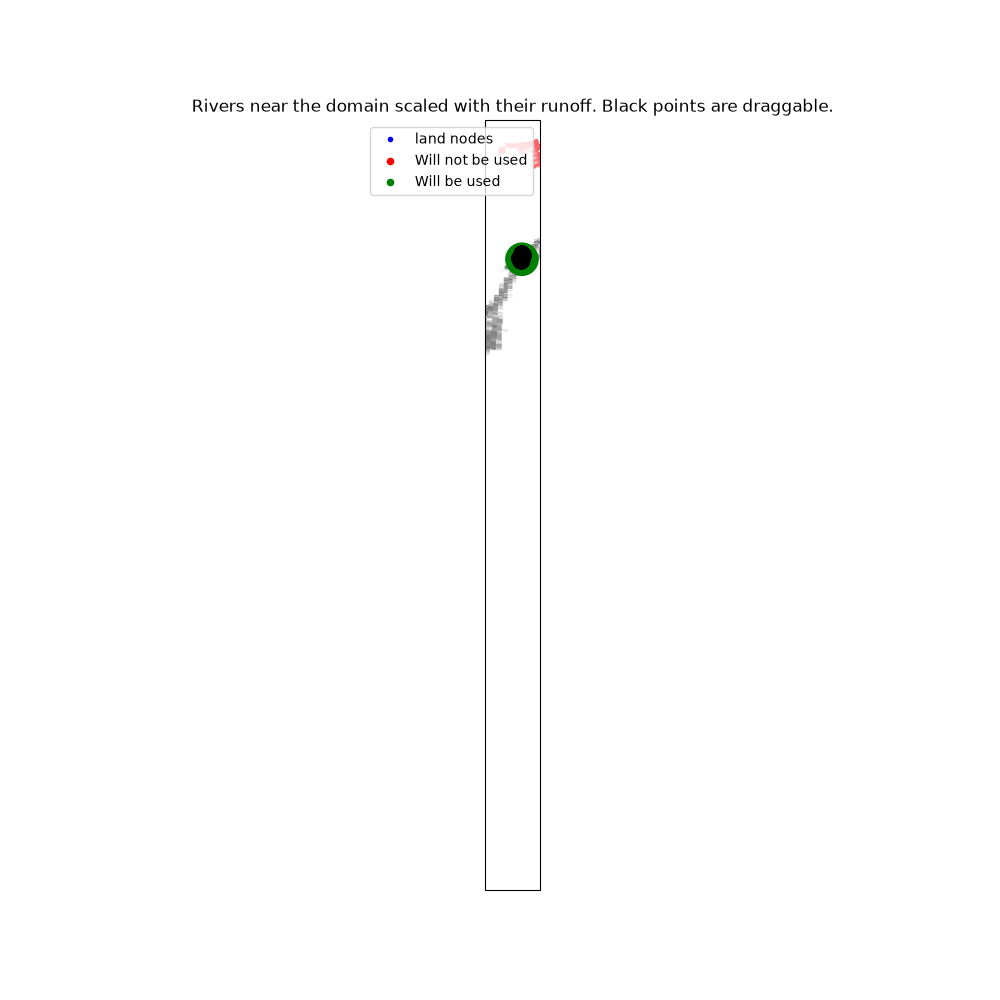

- The river database was adjusted for this experiment, storing it as river_positions_Seaweed.csv
- Remove rivers that discharge within 5000 m from the open boundary
- Determine runoff from rivers by the rivers catchment area

Add temperature profiles to the rivers
- read temperature databases from /nird/datapeak/NS9067K/store/fvcom-setup/Rivers/Temperature/, calculate the river climatology for each watershed
- Add observed temperatures to the rivers where available
- Set the runoff and temperauture for each river in the model, interpolate to model time

Connect rivers to the mesh
- merge rivers that go to the same mesh point

Finished, plotting the forcing


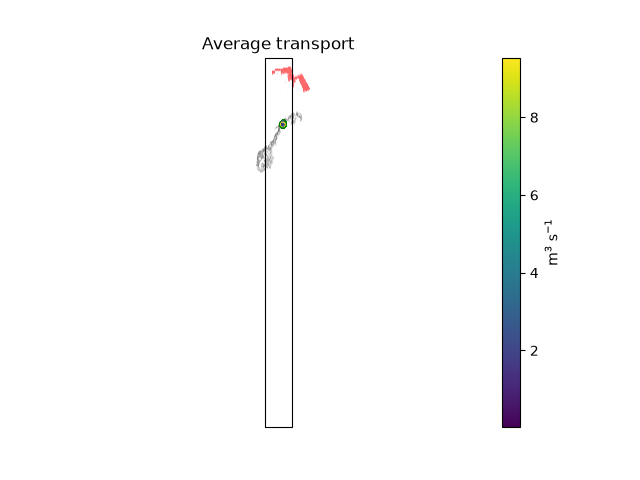

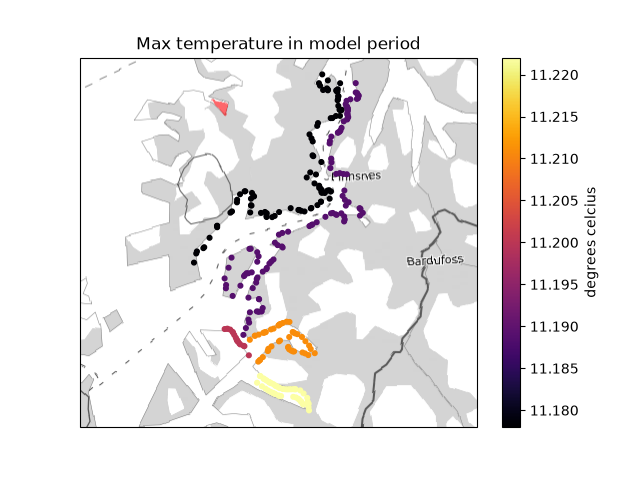

In [3]:
%matplotlib widget
await br.main('2017-09-01', '2018-01-01', [190, 191, 192, 193, 194], 'M.npy')

# Make the atmospheric forcing

In [1]:
import fvtools.atm.read_metCoop as rm

In [2]:
rm.main?

Signature: rm.main(grd_file, outfile, start_time, stop_time, latlon=False)
Docstring:
Create AROME atmospheric forcing file for FVCOM 

Parameters:
----
grd_file:   'M.npy' or equivalent
outfile:     name of netcdf output
start_time: 'yyyy-mm-dd-hh'
stop_time:  'yyyy-mm-dd-hh'
latlon:     Set true if you are making a latlon model (will otherwise rotate to adjust for UTM north/east distortion)
File:      ~\documents\fvtools\fvtools\atm\read_metcoop.py
Type:      function

In [3]:
rm.main('M.npy', 'Seaweed_wnd_sep_2_2017.nc', '2017-09-08-00', '2017-09-20-00')


Create Seaweed_wnd_sep_2017.nc - unstuctured grid atmospheric forcing file
---
- Load M.npy
- Load AROME grid
- Make a filelist
  - found data for 2017-09-08 00:00:00
  - found data for 2017-09-09 00:00:00
  - found data for 2017-09-10 00:00:00
  - found data for 2017-09-11 00:00:00
  - found data for 2017-09-12 00:00:00
  - found data for 2017-09-13 00:00:00
  - found data for 2017-09-14 00:00:00
  - found data for 2017-09-15 00:00:00
  - found data for 2017-09-16 00:00:00
  - found data for 2017-09-17 00:00:00
  - found data for 2017-09-18 00:00:00
  - found data for 2017-09-19 00:00:00
  - found data for 2017-09-20 00:00:00
- Compute interpolation coefficients
  - Finding nearest 4 node weights
  - Finding nearest 4 cell weights
  - Compute interpolation indices and coefficients without land points

Dump to outfile
---
